In [1]:
# Manipulação de dados e visualização
import re
import pandas as pd
import numpy as np
import unicodedata
import seaborn as sns
import matplotlib.pyplot as plt

# Pré-Processamento e Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [3]:
sns.set_style('whitegrid')
%matplotlib inline

## Carregando e Compreendendo os Dados

É o primeiro contato com a matéria-prima do projeto. Lemos os dados de uma fonte (no nosso caso, um arquivo CSV) para um DataFrame do Pandas e realizamos uma verificação inicial para entender sua estrutura.

In [6]:
df = pd.read_csv('dataset.csv')

In [8]:
df.shape

(500, 3)

In [10]:
df.head()

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
1,2,NaN,negativo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo


In [12]:
df.tail()

,review_id,texto_review,sentimento
495,496,Odiei o teclado. Qualidade de baixa qualidade ...,negativo
496,497,Estou muito impressionado com a compra. O moni...,positivo
497,498,Não recomendo. A entrega demorou uma eternidad...,negativo
498,499,Estou muito arrependido com esta compra. Dinhe...,negativo
499,500,Ótimo custo-benefício. O cadeira gamer é incrí...,positivo


In [14]:
df.sample(10)

,review_id,texto_review,sentimento
131,132,Recebi o mouse hoj.e Vou começar a usar para v...,positivo
491,492,Amei o monitor! A qualidade é ótima e a entreg...,positivo
473,474,O cadeira gamer é frágil. O suporte ao cliente...,negativo
139,140,Amei o mouse! A qualidade é excelente e a entr...,positivo
160,161,O notebook é exatamente como descrito no anúnc...,positivo
169,170,"Excelente monitor, superou minhas expetcativas...",positivo
305,306,Não recomendo. A entrega atrasou muito e o mou...,negativo
361,362,Estou muito arrependido com esta compra. Dinhe...,negativo
105,106,Não recomendo. A entrega foi lenta e o livro n...,negativo
88,89,ESTOU MUITO DECEPCIONADO COM ESTA COMPRA. DINH...,negativo


## Análise Exploratória de Dados (EDA)

A fase de investigação. Aqui, "mergulhamos" nos dados para descobrir padrões, anomalias e insights. Utilizamos gráficos (como a contagem de sentimentos positivos vs. negativos) e estatísticas para entender a distribuição e as características dos dados antes de qualquer modificação.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   review_id     500 non-null    int64 
 1   texto_review  488 non-null    object
 2   sentimento    500 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.8+ KB


In [19]:
# verificando valres ausentes

print(df.isnull().sum())

review_id        0
texto_review    12
sentimento       0
dtype: int64


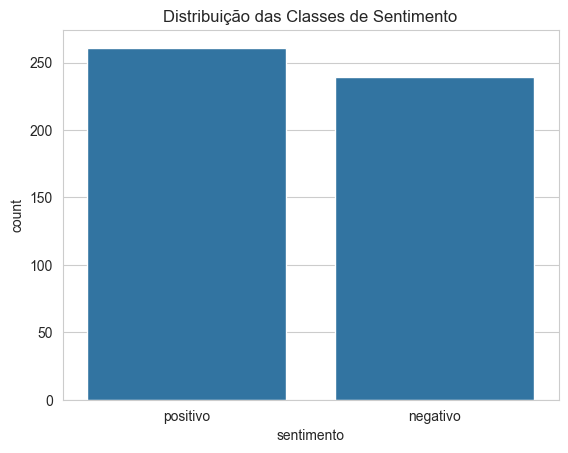

In [21]:
# verificando as classes

sns.countplot(x='sentimento',data=df)
plt.title("Distribuição das Classes de Sentimento")
plt.show()

## Limpeza de Dados

Nesta etapa corrigimos os problemas identificados na EDA. Isso inclui tratar valores ausentes (por exemplo, removendo as linhas correspondentes), garantir que os dados estejam no formato correto e aplicar a função de limpeza de texto (limpa_texto) para normalizar os reviews, removendo acentos, pontuações e caracteres indesejados.

In [27]:
# remover valores ausentes

print(f"Tamanho original do dataframe: {len(df)}\n")
df.dropna(subset=['texto_review'], inplace=True)
print(f"Tamanho do dataframe após remover valores ausentes: {len(df)}\n")

Tamanho original do dataframe: 500

Tamanho do dataframe após remover valores ausentes: 488



In [29]:
df.shape

(488, 3)

In [31]:
df.head()

,review_id,texto_review,sentimento
0,1,Estou muito feliz com a compra. O cadeira game...,positivo
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo
3,4,O monitor é decepcionante. O suporte ao client...,positivo
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo


In [33]:
# Função de limpeza do texto

def limpa_texto(texto):
    """
    Função completa de limpeza de texto:
    1. Converte para minúsculas.
    2. Remove acentos e cedilha.
    3. Remove pontuações, números e caracteres especiais.
    4. Remove espaços extras
    """

    # garante que o texto não seja nulo (caso haja algum nan no dataframe)
    if not isinstance(texto, str):
        return ""

    # normalizar e remover acentos
    # normaliza para a forma 'NFKD' que separa o caractere da acentuação e depois remove os acentos
    texto_sem_acentos = ''.join(c for c in unicodedata.normalize('NFKD', texto) if unicodedata.category(c) != 'Mn')

    
    # limpeza com regex
    # converter para letras minúsculas
    texto_limpo = texto_sem_acentos.lower()

    # manter apenas espaços e letras
    texto_limpo = re.sub(r'[^a-z\s]', '', texto_limpo)

    # remover espaços extras
    texto_limpo = re.sub(r'\s+', ' ', texto_limpo).strip()


    return texto_limpo

In [35]:
# aplica a função no dataframe

df['texto_limpo'] = df['texto_review'].apply(limpa_texto)

In [37]:
df.head()

,review_id,texto_review,sentimento,texto_limpo
0,1,Estou muito feliz com a compra. O cadeira game...,positivo,estou muito feliz com a compra o cadeira gamer...
2,3,Não recomendo. A entrega foi lenta e o celular...,negativo,nao recomendo a entrega foi lenta e o celular ...
3,4,O monitor é decepcionante. O suporte ao client...,positivo,o monitor e decepcionante o suporte ao cliente...
4,5,É UM LIVRO OK PELO PRÇEO QUE PAGUEI.,negativo,e um livro ok pelo prceo que paguei
5,6,Não rceomendo. A entrega atrasou muito e o mon...,positivo,nao rceomendo a entrega atrasou muito e o moni...


## Engenharia de Atributos

É a etapa onde transformamos dados brutos em "features" (atributos) úteis para o modelo. No nosso projeto, isso envolveu a criação da coluna texto_limpo e, mais importante, a conversão das classes de texto ('positivo', 'negativo') em um formato numérico (sentimento_label: 1, 0).

In [40]:
# mapeando os sentimentos para valores numéricos

df["sentimento_label"] = df["sentimento"].map({"positivo": 1, "negativo": 0})

In [42]:
df[["texto_limpo", "sentimento_label"]].sample(10)

,texto_limpo,sentimento_label
82,otimo custobeneficio o fone de ouvido e otima ...,0
194,a cor do fone de ouvido e um pouco diferente d...,1
76,simplesmente perfeito o monitor funciona muito...,1
322,estou muito impressionado com a compra o noteb...,1
406,estou muito frustrado com esta compra dinheiro...,0
432,estou muito feliz com a compra o mouse e incri...,1
282,e um cadeira gamer ok pelo preco que paguei,0
16,pessima experiencia o mouse quebrou no primeir...,0
251,odiei o cadeira gamer qualidade pessima e veio...,0
394,odiei o notebook qualidade de baixa qualidade ...,0


## Divisão em Dados de Treino de Teste

Separamos o conjunto de dados em duas partes: uma maior (treino), que o modelo usará para aprender, e uma menor (teste), que será mantida "escondida" do modelo para simular dados novos e avaliar sua real performance após o treinamento.

In [45]:
# definir variáveis de entrada e saída

X = df["texto_limpo"]
y = df["sentimento_label"]

In [47]:
# definir dados de treino e teste

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.25, random_state = 42, stratify = y)

## Pipeline de Modelagem Preditiva

Aqui, construímos uma esteira de produção automatizada para o nosso modelo. O Pipeline do Scikit-learn encapsula todas as etapas de pré-processamento (vetorização TF-IDF, padronização com StandardScaler) e o modelo final (Regressão Logística), garantindo que os mesmos passos sejam aplicados de forma consistente nos dados de treino e nos novos dados.

In [50]:
# pipeline

pipeline = Pipeline([

    ('tfidf', TfidfVectorizer(stop_words = ['de', 'a', 'o', 'que', 'e', 'do', 'da', 'em', 'um'])),

    ('scaler', StandardScaler(with_mean = False)),

    ('logreg', LogisticRegression(solver = 'liblinear', random_state=42, max_iter=1000))
])

O pipeline é composto por três etapas sequenciais, cada uma com um nome ('tfidf', 'scaler', 'logreg') e uma função específica.

### 1. Vetorização dos Dados de Texto ('tfidf', TfidfVectorizer(...))

Aqui usamos o TfidfVectorizer para converter o texto bruto em números. Ele transforma cada review em um vetor numérico, onde cada número representa a importância de uma palavra naquele texto em relação a todos os outros textos. Palavras comuns como 'de', 'a', 'o', etc., são ignoradas (stop_words).

### 2. Padronização de Dados ('scaler', StandardScaler(with_mean=False))

A segunda etapa, 'scaler', pega os vetores numéricos criados pela etapa anterior e os padroniza. O StandardScaler ajusta a escala de todos os números para que tenham uma variância semelhante. O parâmetro with_mean=False é essencial aqui, pois a matriz de dados do TF-IDF é "esparsa" (cheia de zeros), e essa opção preserva essa característica, evitando problemas de memória e computação.

### 3. Modelo de Machine Learning ('logreg', LogisticRegression(...))

A etapa final, 'logreg', é o modelo de classificação em si. A LogisticRegression recebe os dados numéricos, já padronizados, e aprende a fazer a previsão final: classificar o texto como "positivo" ou "negativo".


O grande benefício do pipeline é a automação e a consistência. Ao treinar este pipeline, ele aprende a fazer todas as três coisas. Depois, quando você apresenta um novo texto para ele prever, o pipeline automaticamente executa a mesma sequência exata de vetorização, padronização e classificação, garantindo que não haja erros no pré-processamento.

### 4. Otimização de Hiperparâmetros

É o ajuste fino do modelo. Usando GridSearchCV, testamos sistematicamente várias combinações de configurações (hiperparâmetros) para o pipeline, a fim de encontrar a combinação que resulta na melhor performance possível.

In [54]:
# definir os hiperparametros para otimização

parametros_grid = {
    'tfidf__max_features': [500, 1000, 2000],
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'logreg__C': [0.1, 1, 10],
    'logreg__penalty': ['l1', 'l2'],
    'logreg__max_iter': [5000, 6000]
}

In [56]:
# configurar o GridSearchCV 

grid_search = GridSearchCV(
    pipeline,                                 # pípeline com as etapas do pré-processamento e modelo
    parametros_grid,                          # Dicionario com as combinações de hiperparâmetros a serem testados
    cv = 5,                                   # número de divisões para a validação cruzada (5 fold cross validation)
    n_jobs = -1,                              # usa todos os núcleoes disponíveis do processador para acelerar o processo
    scoring = 'accuracy',                     # métrica usada para avaliar o desempenho do modelo, aqui acurácia
    verbose = 1                               # nível de detalhamento do output durante a execução (1 exibe progresso básico)
)

GridSearchCV - Validação cruzada é uma técnica usada para avaliar o desempenho de um modelo dividindo o conjunto de dados em várias partes (ou “folds”). O modelo é treinado em algumas dessas partes e testado em outras, de forma rotativa. Isso permite medir o desempenho de forma mais confiável e geral, evitando que o resultado dependa apenas de uma única divisão dos dados.

### 5. Treinamento do Modelo

Nesta etapa, alimentamos o pipeline com os dados de treino. O GridSearchCV executa o processo de .fit(), onde o algoritmo aprende os padrões que conectam o texto dos reviews aos seus respectivos sentimentos.

In [60]:
# treinando o modelo

grid_search.fit(X_treino, y_treino)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('tfidf',
                                        TfidfVectorizer(stop_words=['de', 'a',
                                                                    'o', 'que',
                                                                    'e', 'do',
                                                                    'da', 'em',
                                                                    'um'])),
                                       ('scaler',
                                        StandardScaler(with_mean=False)),
                                       ('logreg',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42,
                                                           solver='liblinear'))]),
             n_jobs=-1,
             param_grid={'logreg__C': [0.1, 1, 10],
                         'logreg__max_iter': [5000, 6000],
                         'logreg__penalty': ['l1', 'l2'],
                         'tfidf__max_features': [500, 1000, 2000],
                         'tfidf__ngram_range': [(1, 1), (1, 2)]},
             scoring='accuracy', verbose=1)

In [62]:
print("Melhores hiperparâmetros encontrados\n")
print(grid_search.best_params_)

Melhores hiperparâmetros encontrados

{'logreg__C': 0.1, 'logreg__max_iter': 5000, 'logreg__penalty': 'l1', 'tfidf__max_features': 500, 'tfidf__ngram_range': (1, 1)}


In [64]:
# obtendo o melhor modelo

melhor_modelo = grid_search.best_estimator_

## Avaliação do Modelo e Interpretação de Métricas

É a "prova final". Usamos o conjunto de teste (os dados que o modelo nunca viu) para fazer previsões e compará-las com os resultados reais. Métricas como Acurácia, Relatório de Classificação e a Matriz de Confusão nos dizem quão bem o modelo está generalizando e se ele atende aos objetivos de negócio.

In [67]:
# previsões usando os dados de teste

y_pred = melhor_modelo.predict(X_teste)

In [69]:
# calcular métricas de avaliação

acuracia = accuracy_score(y_teste, y_pred)
report = classification_report(y_teste, y_pred, target_names = ["Negativo", "Positivo"])

In [71]:
print(f"Acurácia do modelo: {acuracia:.2%}\n")
print("--------------------------\n")
print("Relatório de Classificação\n")
print(report)

Acurácia do modelo: 81.15%

--------------------------

Relatório de Classificação

              precision    recall  f1-score   support

    Negativo       0.80      0.81      0.80        58
    Positivo       0.83      0.81      0.82        64

    accuracy                           0.81       122
   macro avg       0.81      0.81      0.81       122
weighted avg       0.81      0.81      0.81       122



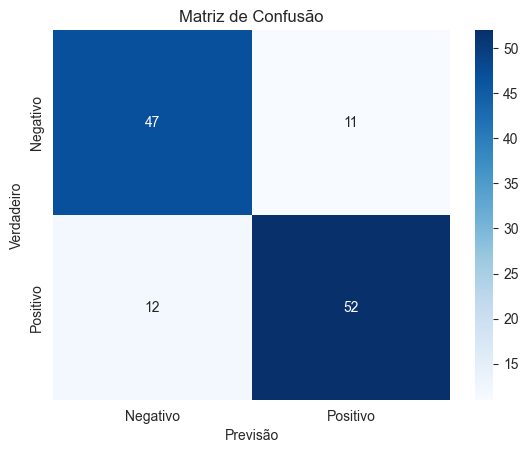

In [73]:
# matriz de confusão

cm = confusion_matrix(y_teste, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Negativo', 'Positivo'],
            yticklabels = ['Negativo', 'Positivo'])
plt.xlabel("Previsão")
plt.ylabel("Verdadeiro")
plt.title("Matriz de Confusão")
plt.show()

**1. Acurácia (Accuracy)**

De todos os reviews (positivos e negativos) que o modelo analisou, qual a porcentagem total de acertos?

Em nosso contexto: Se você passou 100 reviews pelo modelo e ele acertou a classificação de 81 deles (independentemente de serem positivos ou negativos), a acurácia é de 81%. É a medida mais geral de performance.

**2. Precisão (Precision)**

Esta métrica é calculada para cada classe.

Precisão para a classe 'Positivo': Dos reviews que o modelo rotulou como 'Positivos', quantos eram realmente Positivos?

Exemplo: Se o modelo marcou 10 reviews como "Positivos", mas apenas 9 deles eram de fato positivos (e 1 era um erro, um falso positivo), a precisão para a classe 'Positivo' é de 90%.

Importância: Uma alta precisão aqui significa que você pode confiar na etiqueta "Positivo". Se você for usar esses reviews em um material de marketing, por exemplo, não quer mostrar acidentalmente um review negativo.

Precisão para a classe 'Negativo': Dos reviews que o modelo rotulou como 'Negativos', quantos eram realmente Negativos?

Exemplo: Se o modelo marcou 10 reviews como "Negativos" e todos os 10 eram de fato negativos, a precisão para a classe 'Negativo' é de 100%.

Importância: Essencial para a equipe de suporte. Uma alta precisão aqui garante que o tempo da equipe não seja gasto analisando reviews que na verdade eram positivos (falsos negativos para o time de suporte).

**3. Recall**

Esta métrica também é calculada para cada classe.

Recall para a classe 'Positivo': De todos os reviews que realmente eram Positivos, quantos o seu modelo conseguiu encontrar?

Exemplo: Se existiam 12 reviews positivos no total, mas o seu modelo só conseguiu identificar 9 deles (deixando 3 passarem despercebidos), o recall para a classe 'Positivo' é de 75% (9 de 12).

Importância: Um alto recall aqui garante que você está capturando a maior parte do feedback positivo. Você não está perdendo a oportunidade de identificar clientes satisfeitos.

Recall para a classe 'Negativo': De todos os reviews que realmente eram Negativos, quantos o seu modelo conseguiu encontrar?

Exemplo: Se existiam 10 clientes insatisfeitos (reviews negativos), e o modelo identificou 9 deles, o recall para 'Negativo' é de 90%. Ele "deixou escapar" um cliente insatisfeito.

Importância: Talvez a métrica mais crítica para a gestão de crises. Um alto recall para 'Negativo' é vital para garantir que quase nenhuma reclamação passe despercebida e que a equipe de suporte possa agir.

**4. F1-Score**

Qual é o balanço equilibrado entre a Precisão e o Recall para cada classe?

Exemplo: É uma única nota que combina as duas métricas anteriores. O F1-Score para a classe 'Positivo' só será alto se tanto a precisão quanto o recall para 'Positivo' forem altos. Ele evita o cenário onde um modelo é ótimo em uma métrica, mas péssimo em outra. É frequentemente a melhor métrica para avaliar a performance do modelo em uma classe específica.

**5. Support (Suporte)**

Quantos reviews de cada classe realmente existiam no meu conjunto de teste?

Exemplo: Se o relatório mostra um support de 58 para 'Positivo' e 62 para 'Negativo', significa que no seu conjunto de dados de teste havia 58 reviews positivos e 62 negativos.

Importância: Dá contexto aos resultados. Se o support de uma classe for muito baixo, as métricas de performance para essa classe são menos confiáveis, pois foram calculadas com base em poucos exemplos.

## MLOps, Deploy e Uso do Modelo

A etapa final, onde o modelo começa a gerar valor real. "Deploy" significa colocar o modelo treinado em produção. No nosso caso, simulamos isso criando a função dsa_prever_sentimento, que encapsula o pipeline treinado e pode ser usada para classificar novos reviews de forma rápida e automática.

In [ ]:
# salvando o modelo em disco

joblib.dump(melhor_modelo, 'modelo_sentimentov1.joblib')

In [80]:
del melhor_modelo